In [2]:
import numpy as np
np.bool = np.bool_ 
import pandas as pd
import os
from tqdm import tqdm

import mxnet as mx
from mxnet import gluon
from mxnet import autograd
from mxnet import image

import sys

from sklearn.metrics import matthews_corrcoef
from scipy.stats import pearsonr

import random

import rasterio
from rasterio.enums import ColorInterp
from rasterio.features import shapes
from scipy import ndimage

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

import higra as hg
import torch
import pickle

import itertools

import imageio.v3 as imageio
from skimage.color import label2rgb
import cv2
from skimage.segmentation import mark_boundaries
from skimage.segmentation import find_boundaries

from shapely.geometry import shape
import shapely
from shapely import Polygon, MultiPolygon, orient_polygons
from shapely.plotting import plot_polygon
from shapely import ops
from shapely.ops import polygonize, polygonize_full
from shapely.geometry import box
from shapely.ops import transform as shapely_transform

import ast

import pyproj

import geopandas as gpd

import seaborn as sns

import matplotlib.font_manager as fm
import matplotlib.colors as colors

# Map product summary figure

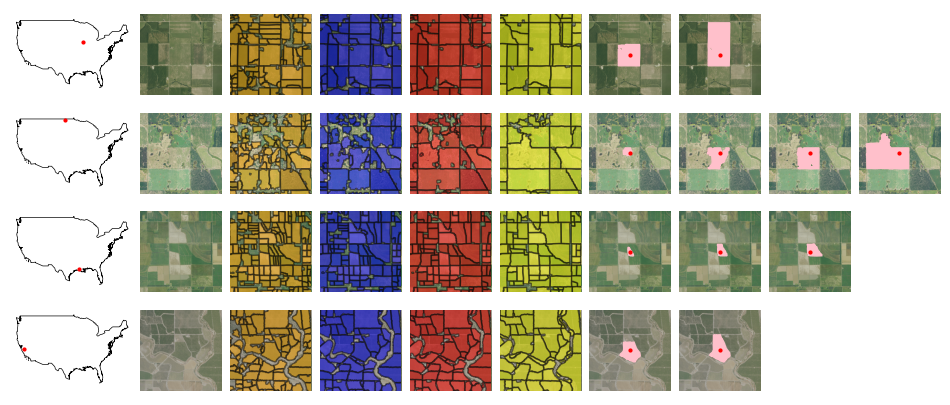

In [3]:
def convert_to_shapely(x):
    x = shapely.from_geojson(x)
    if x.geom_type == 'GeometryCollection':
        polygons = list(polygonize(x.geoms))
        if len(polygons) == 1:
            return polygons[0]
        elif len(polygons) > 1:
            return MultiPolygon(polygons)
        else:
            raise ValueError("invalid geometry")
    else:
        return x
        
T_confidence_set = [0.005, 0.02, 0.08, 0.2]
colors = ['orange', 'blue', 'red', 'yellow']

regions = ['midwest', 'great_plains', 'south', 'west']
midwest_point = [-90.30204846117809, 41.097206010891554]
great_plains_point = [-99.41088516288478, 48.65143353949601]
south_point = [-92.56075789374566, 30.05048376949548]
west_point = [-120.55142458433284, 37.034699470077015]
points = [midwest_point, great_plains_point, south_point, west_point]
num_examples = len(regions)

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=num_examples, ncols=10, figsize=(12, 5), gridspec_kw={'width_ratios': [1.5]+list(np.ones(9))})
for ax in axs.ravel():
    ax.axis('off')

for i in range(num_examples):
    region = regions[i]
    coord = points[i] 
    
    image_filename = f'figures/map_product_visualizations/image_{region}.tif'
    image = imageio.imread(image_filename)
    rgb_img = image[:, :, :3]
    src = rasterio.open(image_filename)
    col, row = src.index(coord[0], coord[1])
    
    def coordinate_transform(x, y):
        col, row = src.index(x, y)
        return (row, col)

    fields = pd.read_csv(f'figures/map_product_visualizations/all_fields_{region}.csv')
    fields['field_prediction'] = fields['.geo'].apply(lambda x: convert_to_shapely(x))

    prediction_set = pd.read_csv(f'figures/map_product_visualizations/prediction_set_{region}.csv')
    prediction_set['field_prediction'] = prediction_set['.geo'].apply(lambda x: convert_to_shapely(x))
    prediction_set = prediction_set.sort_values(by='watershed_threshold')
    
    # PLOTTING
    ax = axs[i, 0]
    world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
    usa = world[world.admin == "United States of America"]
    usa.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)
    ax.plot(coord[0], coord[1], "o", color="red", markersize=2)
    ax.set_xlim(-128, -65)
    ax.set_ylim(23, 50)
    
    for j in range(1, 6+len(prediction_set)):
        ax = axs[i, j]
        ax.imshow(rgb_img)
        ax.set_xlim(64, 512-64)
        ax.set_ylim(512-64, 64)
        
    for j, T in enumerate(T_confidence_set):
        ax = axs[i, j+2]
        fields_epsg4326 = fields[fields['watershed_threshold']==T]['field_prediction']
        for field_epsg4326 in fields_epsg4326:
            field = shapely_transform(coordinate_transform, field_epsg4326)
            plot_polygon(field, ax=ax, add_points=False, alpha=0.5, facecolor=colors[j], linewidth=1, edgecolor='black')

    for j in range(len(prediction_set)):
        ax = axs[i, j+6]
        field_epsg4326 = prediction_set['field_prediction'].iloc[j]
        field = shapely_transform(coordinate_transform, field_epsg4326)
        plot_polygon(field, ax=ax, add_points=False, alpha=1, color='pink')
        ax.plot(col, row, "o", color="red", markersize=2)

plt.subplots_adjust(hspace=0.1)
plt.subplots_adjust(wspace=0.1)
plt.savefig('figures/map_product_summary.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [4]:
data_unfiltered = pd.read_csv('figures/map_product_visualizations/random_points_set_size_field_size.csv')
data_unfiltered['lat'] = data_unfiltered['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][1])
data_unfiltered['lon'] = data_unfiltered['.geo'].apply(lambda x: ast.literal_eval(x)["coordinates"][0])
data_unfiltered.drop(columns=['.geo'], inplace=True)
data_unfiltered['field_size'] = data_unfiltered['field_size']/10000 # convert from square meters to hectares

data = data_unfiltered[data_unfiltered['field_size'] > 0].reset_index()
print("Number of points:", len(data_unfiltered))
print("Number of points contained in a Single Best Parameter field:", len(data))
data = data[:40000]
print("Number of points used for visualization:", len(data))

grid_cell_width = 0.25
def find_grid_cell_id(lon, lat):
    new_lon = grid_cell_width * np.floor(lon/grid_cell_width)
    new_lat = grid_cell_width * np.floor(lat/grid_cell_width)
    return (new_lon, new_lat)
data['grid_cell_id'] = data.apply(lambda x: find_grid_cell_id(x['lon'], x['lat']), axis=1)
data_summary = data[['conformal_set_size', 'field_size', 'grid_cell_id']].groupby("grid_cell_id").agg(
    count=('conformal_set_size', 'size'),
    conformal_set_size=('conformal_set_size', 'mean'),
    field_size=('field_size', 'mean')
).reset_index()
data_summary["grid_cell"] = data_summary["grid_cell_id"].apply(lambda x: box(x[0], x[1], x[0]+grid_cell_width, x[1]+grid_cell_width))
data_summary = data_summary[data_summary['count']>=5].reset_index(drop=True) # only keep grid cells with many points
display(data_summary)

Number of points: 50000
Number of points contained in a Single Best Parameter field: 45162
Number of points used for visualization: 40000


,grid_cell_id,count,conformal_set_size,field_size,grid_cell
0,"(-123.25, 45.0)",6,2.833333,20.333303,"POLYGON ((-123 45, -123 45.25, -123.25 45.25, ..."
1,"(-123.25, 45.25)",6,2.166667,14.809012,"POLYGON ((-123 45.25, -123 45.5, -123.25 45.5,..."
2,"(-123.0, 44.75)",5,2.400000,18.345413,"POLYGON ((-122.75 44.75, -122.75 45, -123 45, ..."
3,"(-123.0, 45.0)",8,2.375000,20.076463,"POLYGON ((-122.75 45, -122.75 45.25, -123 45.2..."
4,"(-122.5, 39.5)",5,2.400000,56.001931,"POLYGON ((-122.25 39.5, -122.25 39.75, -122.5 ..."
...,...,...,...,...,...
3321,"(-75.75, 39.25)",6,2.333333,32.971832,"POLYGON ((-75.5 39.25, -75.5 39.5, -75.75 39.5..."
3322,"(-75.75, 43.0)",5,2.000000,9.243953,"POLYGON ((-75.5 43, -75.5 43.25, -75.75 43.25,..."
3323,"(-75.5, 38.25)",7,2.428571,15.806699,"POLYGON ((-75.25 38.25, -75.25 38.5, -75.5 38...."
3324,"(-75.5, 39.5)",8,2.250000,20.794114,"POLYGON ((-75.25 39.5, -75.25 39.75, -75.5 39...."


In [5]:
data['conformal_set_size'].value_counts()/len(data)

conformal_set_size
2    0.341850
3    0.305625
1    0.194800
4    0.157725
Name: count, dtype: float64

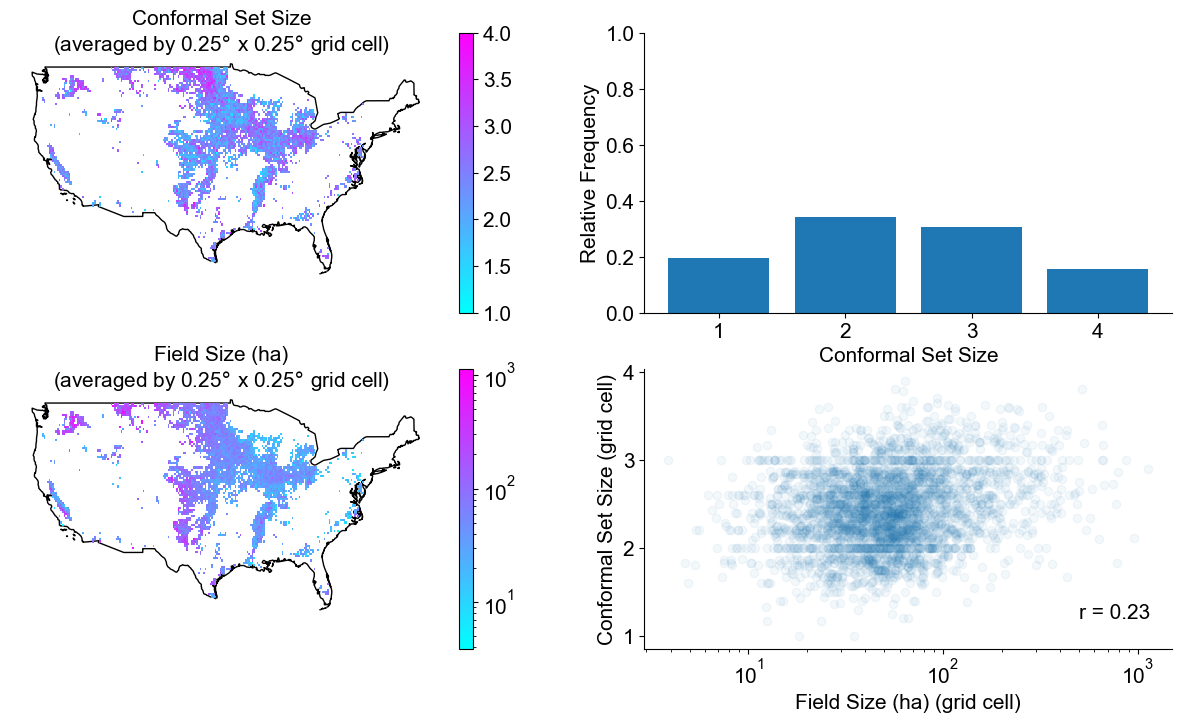

In [6]:
import matplotlib.colors as colors

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

ax = axs[0, 0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    data_summary[['grid_cell', 'conformal_set_size']], geometry=data_summary['grid_cell'], crs="EPSG:4326"
)
sc = gdf.plot(
    ax=ax,
    column='conformal_set_size',
    cmap='cool', 
    vmin=1, 
    vmax=4,
    linewidth=0,
    legend=True,
) 
ax.set_title(f'Conformal Set Size\n(averaged by {grid_cell_width}$\degree$ x {grid_cell_width}$\degree$ grid cell)')
ax.set_axis_off()

ax = axs[0, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.bar(data['conformal_set_size'].value_counts().index, data['conformal_set_size'].value_counts().values/len(data))
ax.set_xticks(np.arange(1, 5))
ax.set_ylim([0, 1])
ax.set_xlabel("Conformal Set Size")
ax.set_ylabel("Relative Frequency")

ax = axs[1, 0]
world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(ax=ax, color='white', edgecolor='black')
ax.set_xlim(-128, -65)
ax.set_ylim(23, 50)
gdf = gpd.GeoDataFrame(
    data_summary[['grid_cell', 'field_size']], geometry=data_summary['grid_cell'], crs="EPSG:4326"
)
sc = gdf.plot(
    ax=ax,
    column='field_size',
    norm=colors.LogNorm(vmin=gdf['field_size'].min(), vmax=gdf['field_size'].max()),
    cmap='cool', 
    linewidth=0,
    legend=True,
) 
ax.set_title(f'Field Size (ha)\n(averaged by {grid_cell_width}$\degree$ x {grid_cell_width}$\degree$ grid cell)')
ax.set_axis_off()

ax = axs[1, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.scatter(data_summary['field_size'], data_summary['conformal_set_size'], alpha=0.05)
ax.set_ylabel("Conformal Set Size (grid cell)")
ax.set_xlabel("Field Size (ha) (grid cell)")
ax.set_xscale('log')
ax.set_xticks([10, 100, 1000])
ax.set_yticks([1, 2, 3, 4])

r = pearsonr(np.log(data_summary['field_size']), data_summary['conformal_set_size']).statistic
r = round(r, 2)
ax.text(500, 1.2, f"r = {r:.2f}")

plt.savefig('figures/random_points_field_size_set_size.png', dpi=300, bbox_inches='tight')
plt.show()

# Field visualization examples for motivating figure and methods figure

In [2]:
def convert_to_shapely(x):
    x = shapely.from_geojson(x)
    if x.geom_type == 'GeometryCollection':
        polygons = list(polygonize(x.geoms))
        if len(polygons) == 1:
            return polygons[0]
        elif len(polygons) > 1:
            return MultiPolygon(polygons)
        else:
            raise ValueError("invalid geometry")
    else:
        return x

T_confidence_set = [0.005, 0.02, 0.08, 0.2]
colors = ['orange', 'blue', 'red', 'yellow']

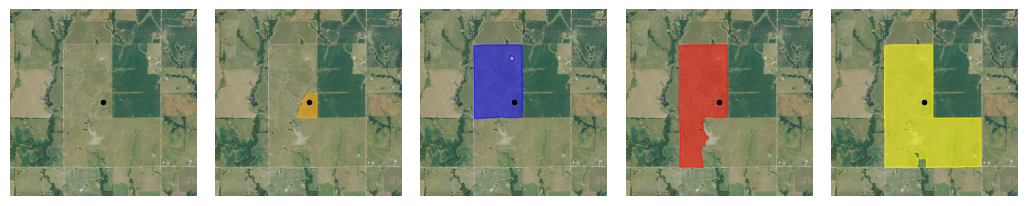

In [22]:
prediction_set = pd.read_csv('figures/map_product_visualizations/prediction_set_motivating_example.csv')
prediction_set['field_prediction'] = prediction_set['.geo'].apply(lambda x: convert_to_shapely(x))

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(13, 5))
for ax in axs.ravel():
    ax.axis('off')
    
image_filename = 'figures/map_product_visualizations/image_motivating_example.tif'
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
src = rasterio.open(image_filename)
coord_epsg4326 = [-95.88661309689668, 38.66130439984234]
col, row = src.index(coord_epsg4326[0], coord_epsg4326[1])

def coordinate_transform(x, y):
    col, row = src.index(x, y)
    return (row, col)

for i in range(5):
    ax = axs[i]
    ax.imshow(rgb_img)
    ax.plot(col, row, "o", color="black", markersize=3)
    ax.set_xlim(64, 512-64)
    ax.set_ylim(512-64, 64)

for i, T in enumerate(T_confidence_set):
    ax = axs[i+1]
    field_epsg4326 = prediction_set[prediction_set['watershed_threshold']==T]['field_prediction'].iloc[0]
    field = shapely_transform(coordinate_transform, field_epsg4326)
    plot_polygon(field, ax=ax, add_points=False, alpha=0.5, color=colors[i])

plt.subplots_adjust(wspace=0.1)
plt.savefig('figures/map_query_example.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

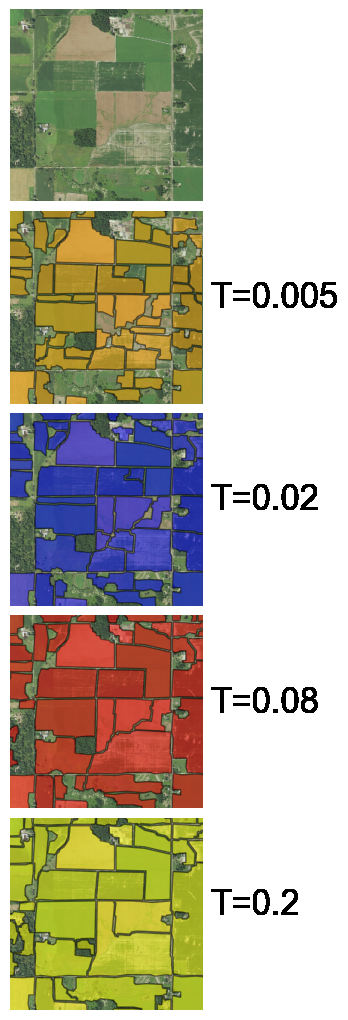

In [3]:
fields = pd.read_csv('figures/map_product_visualizations/all_fields_methods_example.csv')
fields['field_prediction'] = fields['.geo'].apply(lambda x: convert_to_shapely(x))

font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(5, 13))
for ax in axs.ravel():
    ax.axis('off')
    
image_filename = 'figures/map_product_visualizations/image_methods_example.tif'
image = imageio.imread(image_filename)
rgb_img = image[:, :, :3]
src = rasterio.open(image_filename)
coord_epsg4326 = [-89.95475791508905, 44.53215600030691]
col, row = src.index(coord_epsg4326[0], coord_epsg4326[1])

def coordinate_transform(x, y):
    col, row = src.index(x, y)
    return (row, col)

for i in range(5):
    ax = axs[i]
    ax.imshow(rgb_img)
    ax.set_xlim(128, 512-128)
    ax.set_ylim(512-128, 128)
    
for i, T in enumerate(T_confidence_set):
    ax = axs[i+1]
    fields_epsg4326 = fields[fields['watershed_threshold']==T]['field_prediction']
    for field_epsg4326 in fields_epsg4326:
        field = shapely_transform(coordinate_transform, field_epsg4326)
        plot_polygon(field, ax=ax, add_points=False, alpha=0.5, facecolor=colors[i], linewidth=1, edgecolor='black')
        ax.text(512-128+10, 256, f'T={T}', fontsize=25)

plt.subplots_adjust(hspace=0.05)
plt.savefig('figures/map_product_methods_example.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

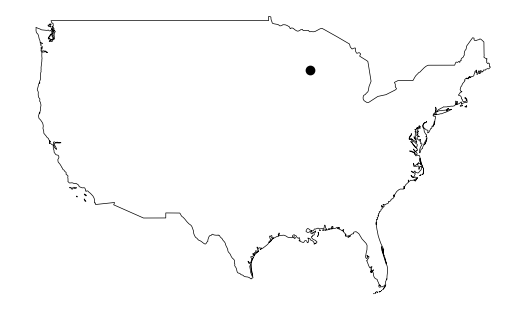

In [15]:
font_path = 'arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=15)          
plt.rc('axes', titlesize=15)     
plt.rc('axes', labelsize=15)    
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)    
plt.rc('figure', titlesize=15)

world = gpd.read_file("https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_50m_admin_0_countries.geojson")
usa = world[world.admin == "United States of America"]
usa.plot(color='white', edgecolor='black', linewidth=0.5)
coord = [-89.95475791508905, 44.53215600030691]
plt.plot(coord[0], coord[1], "o", color="black", markersize=6)

plt.xlim(-128, -65)
plt.ylim(23, 50)
plt.axis('off')
plt.savefig('figures/map_product_methods_example_coordinate.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()